# Zonally integrated temperature change in ocean (Atlantic and non-Atlantic)

Figure S5

Note: CM2.1 and FLOR ocean latitude near tropics is slightly different (very small mismatch) so need to align things in latitude

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

plt.style.use('../func/paper.mplstyle')

In [2]:
def compute_zonal_integral(da, split_basins = False):
    # compute zonal integral of the time mean of the input array da
    
    y_meters = 111 * 1000 * np.cos(da.yt_ocean * np.pi / 180) # get length of grid cell

    if split_basins == False:
        zonal_integral = (da.mean('time') * y_meters).sum(dim='xt_ocean')
        return zonal_integral
    
    if split_basins == True:
        mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED.nc')
        mask = mask.rename({'lat': 'yt_ocean', 'lon': 'xt_ocean'})
        
        if da.yt_ocean.equals(mask.yt_ocean) == False: # align the mask (for CM2.1)
            mask = mask.reindex(yt_ocean=da.yt_ocean, xt_ocean=da.xt_ocean, method="nearest", tolerance=1e-2)
        
        Atlantic = da.where(mask==1)
        nonAtlantic = da.where((mask == 2) | (mask == 3) | (mask == 4))

        Atlantic_zonal_integral = (Atlantic.mean('time') * y_meters).sum(dim='xt_ocean')
        nonAtlantic_zonal_integral = (nonAtlantic.mean('time') * y_meters).sum(dim='xt_ocean')
        
        return Atlantic_zonal_integral, nonAtlantic_zonal_integral
    

# # # cell area: same area for FLOR and CM2.1 ocean
# # area = xr.open_dataarray('../Solar/area_t_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0101_ocean_grid.nc')
# # area = xr.open_dataarray('../Solar/area_t_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0101_ocean_month.nc')
# # area = area.squeeze('time')
# # area.plot()
# # area

# y_meters_FLOR = 110 * 1000 * np.cos(CTRL_FLOR.yt_ocean * np.pi / 180)
# y_meters_CM21 = 110 * 1000 * np.cos(CTRL_CM21.yt_ocean * np.pi / 180)

# plt.plot(CTRL_FLOR.yt_ocean, y_meters_FLOR)
# plt.plot(CTRL_CM21.yt_ocean, y_meters_CM21)

# compute zonal integral: all basins

In [3]:
# load CONTROL data
CTRL_FLOR = xr.open_dataarray('./MODEL_OUT/temp_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0150_output.nc')
CTRL_CM21 = xr.open_dataarray('./MODEL_OUT/temp_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0150_output.nc')

In [4]:
# compute CTRL zonal integral (takes a few minutes)
CTRL_FLOR_zonal_integral = compute_zonal_integral(CTRL_FLOR, split_basins=False)
CTRL_CM21_zonal_integral = compute_zonal_integral(CTRL_CM21, split_basins=False)

Text(0.02, 0.5, 'Depth [m]')

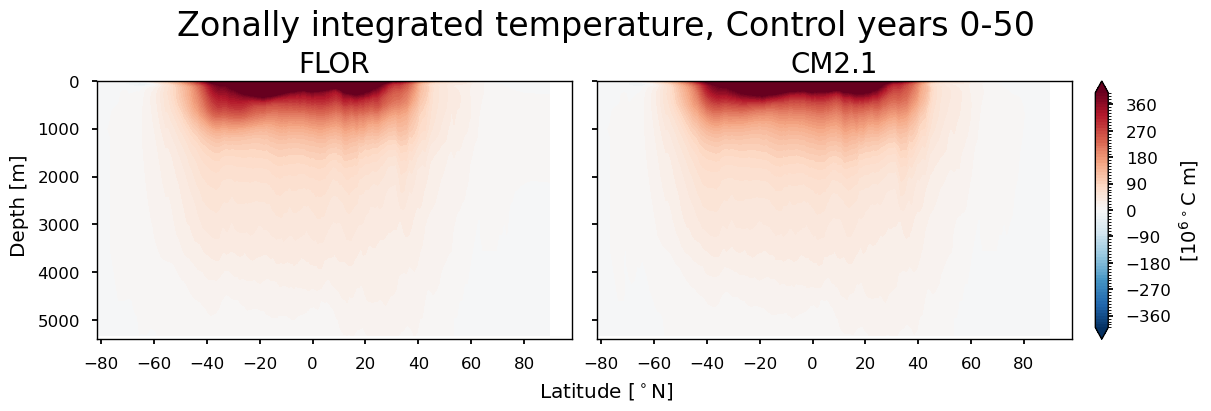

In [5]:
# plot CONTROL
fig, ax = plt.subplots(1,2,figsize=(12,4), sharey=True, sharex=True)

levels = np.arange(-4e2, 4.1e2, 0.1e2)

cf = (CTRL_FLOR_zonal_integral * 1e-6).plot.contourf(ax=ax[0], levels=levels, extend='both', add_colorbar=False)
ax[0].set_title('FLOR')

(CTRL_CM21_zonal_integral * 1e-6).plot.contourf(ax=ax[1], levels=levels, extend='both', add_colorbar=False)
ax[1].set_title('CM2.1')

for axis in ax:
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.set_ylim(5400, 0)
    #axis.set_ylim(m6_FLOR_anomaly.st_ocean.max(), 0)

fig.colorbar(cf, ax=ax[1], label='[$10^6$$^\circ$C m]')
fig.suptitle('Zonally integrated temperature, Control years 0-50')
fig.supxlabel('Latitude [$^\circ$N]')
fig.supylabel('Depth [m]')

In [6]:
# load experiment data
m6_FLOR = xr.open_dataarray('./MODEL_OUT/temp_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0300_output.nc')
m6_CM21 = xr.open_dataarray('./MODEL_OUT/temp_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0300_output.nc')

# select years of interest
m6_FLOR = m6_FLOR.isel(time=slice(20*12,None))
m6_CM21 = m6_CM21.isel(time=slice(20*12,None))

# compute -6% Solar zonal integral
m6_FLOR_zonal_integral = compute_zonal_integral(m6_FLOR, split_basins=False)
m6_CM21_zonal_integral = compute_zonal_integral(m6_CM21, split_basins=False)

# compute anomaly from control
m6_FLOR_anomaly = m6_FLOR_zonal_integral - CTRL_FLOR_zonal_integral
m6_CM21_anomaly = m6_CM21_zonal_integral - CTRL_CM21_zonal_integral

Text(0.5, 1.1, '-6% Solar zonally integrated T anomaly, years 20–200')

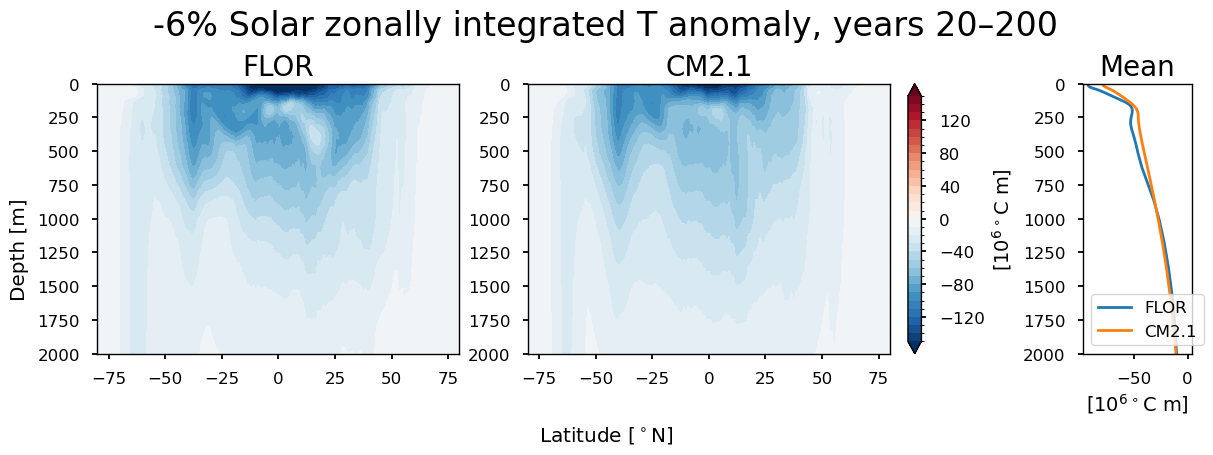

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Create figure with constrained layout
fig = plt.figure(figsize=(12, 4), constrained_layout=True)
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.3], figure=fig)

# Subplots
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0, sharey=ax0)
ax2 = fig.add_subplot(gs[2], sharey=ax0)

levels = np.arange(-1.5e2, 1.6e2, 0.1e2)

# Contour plots
cf = (m6_FLOR_anomaly * 1e-6).plot.contourf(ax=ax0, levels=levels, extend='both', add_colorbar=False)
ax0.set_title('FLOR')

(m6_CM21_anomaly * 1e-6).plot.contourf(ax=ax1, levels=levels, extend='both', add_colorbar=False)
ax1.set_title('CM2.1')

# Line plot (zonal mean)
mean_FLOR = (m6_FLOR_anomaly * 1e-6).mean(dim='yt_ocean')
mean_CM21 = (m6_CM21_anomaly * 1e-6).mean(dim='yt_ocean')

ax2.plot(mean_FLOR, mean_FLOR.st_ocean, label='FLOR')
ax2.plot(mean_CM21, mean_CM21.st_ocean, label='CM2.1')
ax2.set_title('Mean')
ax2.set_xlabel('[$10^6$$^\circ$C m]')
ax2.legend()
ax2.invert_yaxis()

# Axis settings
for ax in [ax0, ax1]:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(2000, 0)
    ax.set_xlim(-80, 80)

# Shared labels and colorbar
fig.colorbar(cf, ax=ax1, label='[$10^6$$^\circ$C m]')
fig.supxlabel('Latitude [$^\circ$N]')
fig.supylabel('Depth [m]')

# Move suptitle up slightly
fig.suptitle('-6% Solar zonally integrated T anomaly, years 20–200', y=1.1)


# Split into Atlantic and non-Atlantic

In [8]:
# Control
CTRL_FLOR_Atlantic_zonal_integral, CTRL_FLOR_nonAtlantic_zonal_integral = compute_zonal_integral(CTRL_FLOR, split_basins=True)
CTRL_CM21_Atlantic_zonal_integral, CTRL_CM21_nonAtlantic_zonal_integral = compute_zonal_integral(CTRL_CM21, split_basins=True)

In [9]:
# compute -6% Solar zonal integral
m6_FLOR_Atlantic_zonal_integral, m6_FLOR_nonAtlantic_zonal_integral = compute_zonal_integral(m6_FLOR, split_basins=True)
m6_CM21_Atlantic_zonal_integral, m6_CM21_nonAtlantic_zonal_integral = compute_zonal_integral(m6_CM21, split_basins=True)

In [10]:
# compute anomaly
m6_FLOR_Atlantic_anomaly = m6_FLOR_Atlantic_zonal_integral - CTRL_FLOR_Atlantic_zonal_integral
m6_FLOR_nonAtlantic_anomaly = m6_FLOR_nonAtlantic_zonal_integral - CTRL_FLOR_nonAtlantic_zonal_integral

m6_CM21_Atlantic_anomaly = m6_CM21_Atlantic_zonal_integral - CTRL_CM21_Atlantic_zonal_integral
m6_CM21_nonAtlantic_anomaly = m6_CM21_nonAtlantic_zonal_integral - CTRL_CM21_nonAtlantic_zonal_integral

/tmp/ipykernel_2114456/80093324.py:61: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('FigureS5.pdf', bbox_inches='tight', dpi=300)
/tmp/ipykernel_2114456/80093324.py:61: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('FigureS5.pdf', bbox_inches='tight', dpi=300)
/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


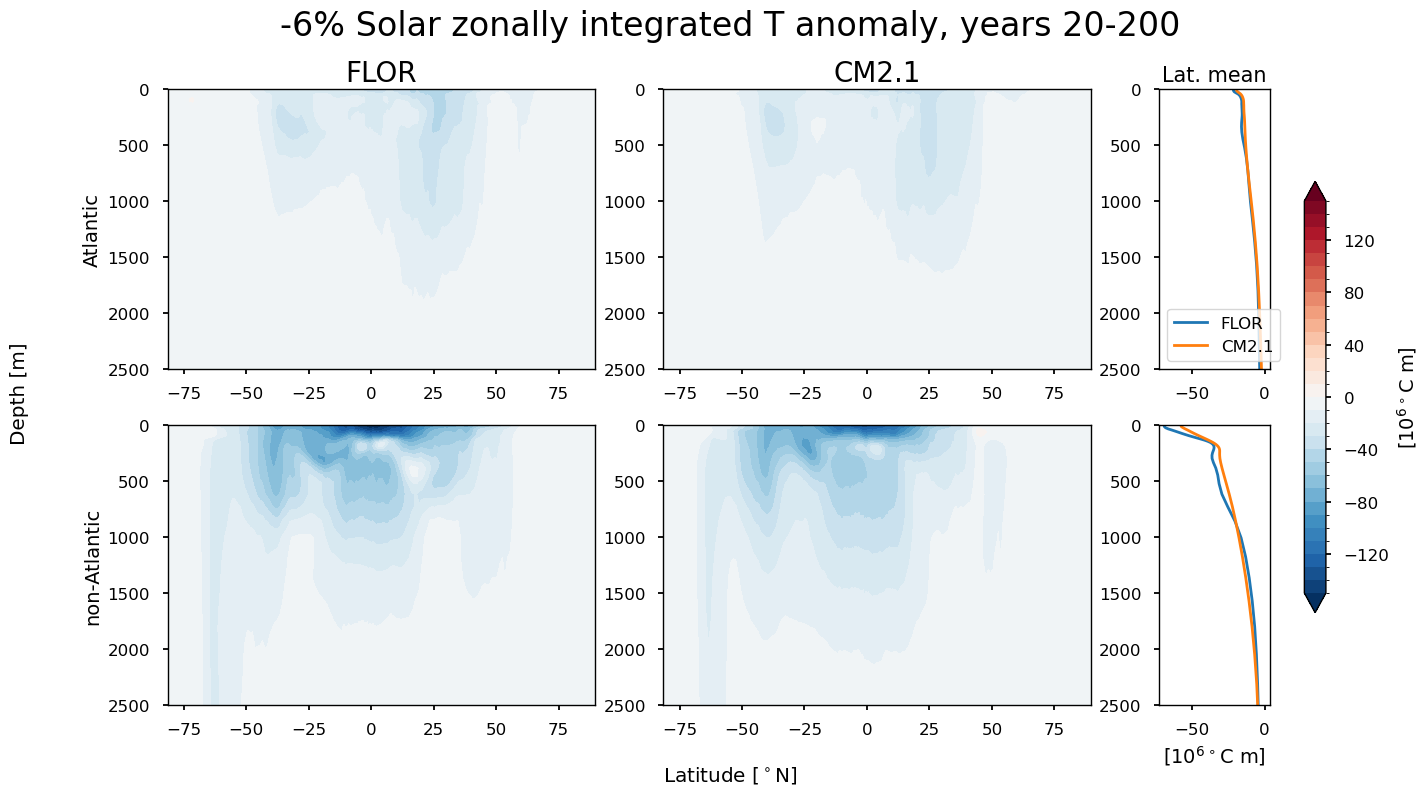

In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use('../func/paper.mplstyle')

# Create figure and gridspec layout
fig = plt.figure(figsize=(15,8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.4])  # make 3rd column narrower

# Create subplot array
ax = np.empty((2, 3), dtype=object)

# Loop through grid and assign shared axes
for i in range(2):
    for j in range(3):
        sharex = ax[0,j] if i > 0 else None  # share x-axis within each column
        sharey = ax[0,0]                    # all share the same y-axis
        ax[i,j] = fig.add_subplot(gs[i,j], sharex=sharex, sharey=sharey)

# Plot settings
levels = np.arange(-1.5e2, 1.6e2, 0.1e2)

# Filled contour plots
cf = (m6_FLOR_Atlantic_anomaly * 1e-6).plot.contourf(ax=ax[0,0], levels=levels, extend='both', add_colorbar=False)
(m6_FLOR_nonAtlantic_anomaly * 1e-6).plot.contourf(ax=ax[1,0], levels=levels, extend='both', add_colorbar=False)
(m6_CM21_Atlantic_anomaly * 1e-6).plot.contourf(ax=ax[0,1], levels=levels, extend='both', add_colorbar=False)
(m6_CM21_nonAtlantic_anomaly * 1e-6).plot.contourf(ax=ax[1,1], levels=levels, extend='both', add_colorbar=False)

# Line plots in the third column
(m6_FLOR_Atlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[0,2], y='st_ocean', label='FLOR')
(m6_CM21_Atlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[0,2], y='st_ocean', label='CM2.1')
ax[0,2].legend()

(m6_FLOR_nonAtlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[1,2], y='st_ocean', label='FLOR')
(m6_CM21_nonAtlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[1,2], y='st_ocean', label='CM2.1')

# Cleanup axis formatting
for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.set_title('')
    axis.set_ylim(2500, 0)  # reverse y-axis

# Titles and labels
ax[0,0].set_title('FLOR')
ax[0,1].set_title('CM2.1')
ax[0,0].set_ylabel('Atlantic')
ax[1,0].set_ylabel('non-Atlantic')
ax[0,2].set_title('Lat. mean', fontsize=15)
ax[1,2].set_xlabel('[$10^6$$^\circ$C m]')

# Add colorbar
fig.colorbar(cf, ax=ax[:,2], label='[$10^6$$^\circ$C m]', orientation='vertical', shrink=0.7, pad=0.2)

# Super labels
fig.suptitle('-6% Solar zonally integrated T anomaly, years 20-200')
fig.supxlabel('Latitude [$^\circ$N]')
fig.supylabel('Depth [m]')

plt.savefig('FigureS5.pdf', bbox_inches='tight', dpi=300)

# Do for +6% Solar

In [20]:
p6_FLOR = xr.open_dataarray('./MODEL_OUT/temp_FLOR_p6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0131-0170_output.nc')
p6_CM21 = xr.open_dataarray('./MODEL_OUT/temp_CM2.1p1_CTL1860_p6pctSolar_tigercpu_intelmpi_18_80PE_0131-0170_output.nc')

# compute -6% Solar zonal integral
p6_FLOR_Atlantic_zonal_integral, p6_FLOR_nonAtlantic_zonal_integral = compute_zonal_integral(p6_FLOR, split_basins=True)
p6_CM21_Atlantic_zonal_integral, p6_CM21_nonAtlantic_zonal_integral = compute_zonal_integral(p6_CM21, split_basins=True)

# compute anomaly
p6_FLOR_Atlantic_anomaly = p6_FLOR_Atlantic_zonal_integral - CTRL_FLOR_Atlantic_zonal_integral
p6_FLOR_nonAtlantic_anomaly = p6_FLOR_nonAtlantic_zonal_integral - CTRL_FLOR_nonAtlantic_zonal_integral

p6_CM21_Atlantic_anomaly = p6_CM21_Atlantic_zonal_integral - CTRL_CM21_Atlantic_zonal_integral
p6_CM21_nonAtlantic_anomaly = p6_CM21_nonAtlantic_zonal_integral - CTRL_CM21_nonAtlantic_zonal_integral

Text(0.02, 0.5, 'Depth [m]')

/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/GEOCLIM/software/anaconda3/2024.10/envs/geoclim/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


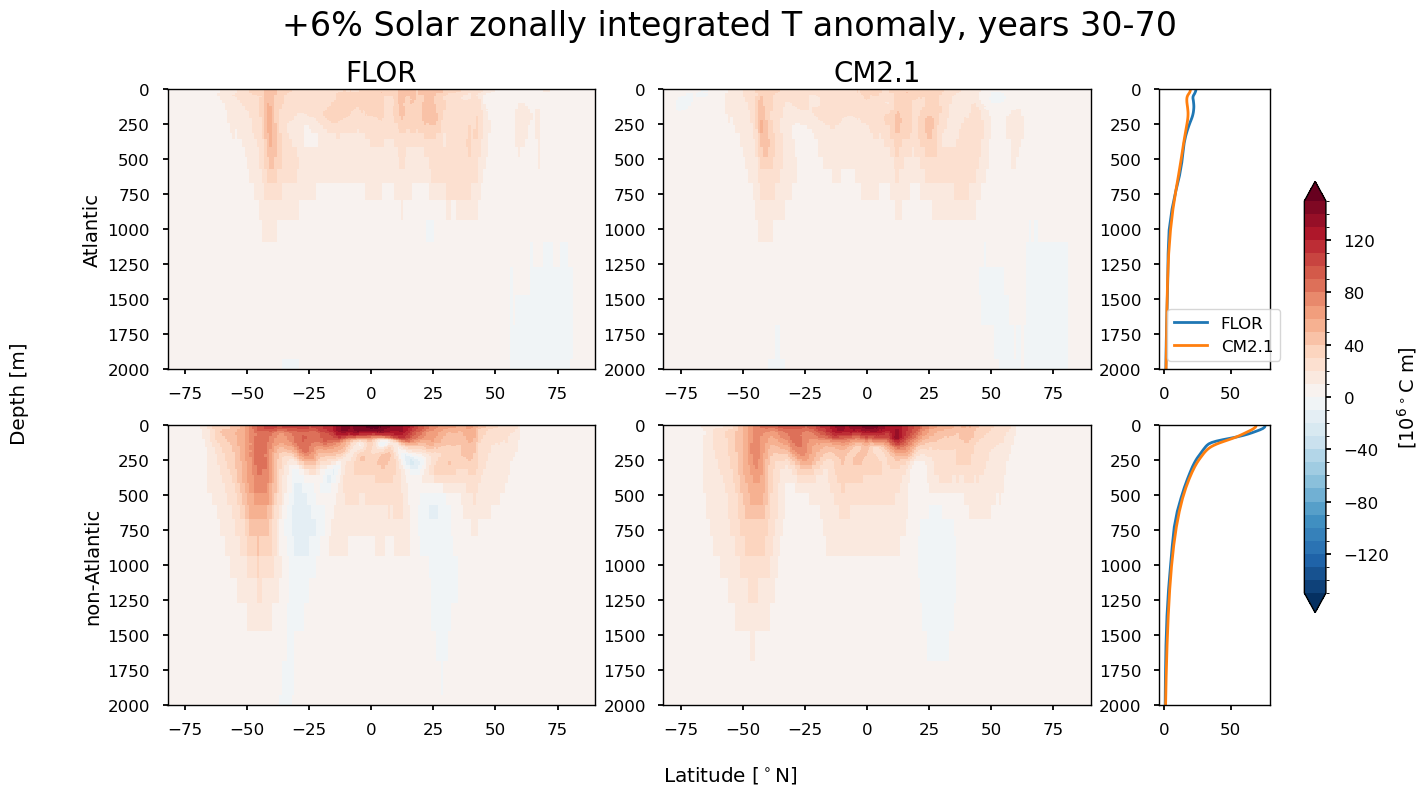

In [61]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Create figure and gridspec layout
fig = plt.figure(figsize=(15,8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.4])  # make 3rd column narrower

# Create subplot array
ax = np.empty((2, 3), dtype=object)

# Loop through grid and assign shared axes
for i in range(2):
    for j in range(3):
        sharex = ax[0,j] if i > 0 else None  # share x-axis within each column
        sharey = ax[0,0]                    # all share the same y-axis
        ax[i,j] = fig.add_subplot(gs[i,j], sharex=sharex, sharey=sharey)

# Plot settings
levels = np.arange(-1.5e2, 1.6e2, 0.1e2)

# Filled contour plots
cf = (p6_FLOR_Atlantic_anomaly * 1e-6).plot(ax=ax[0,0], levels=levels, extend='both', add_colorbar=False)
(p6_FLOR_nonAtlantic_anomaly * 1e-6).plot(ax=ax[1,0], levels=levels, extend='both', add_colorbar=False)
(p6_CM21_Atlantic_anomaly * 1e-6).plot(ax=ax[0,1], levels=levels, extend='both', add_colorbar=False)
(p6_CM21_nonAtlantic_anomaly * 1e-6).plot(ax=ax[1,1], levels=levels, extend='both', add_colorbar=False)

# Line plots in the third column
(p6_FLOR_Atlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[0,2], y='st_ocean', label='FLOR')
(p6_CM21_Atlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[0,2], y='st_ocean', label='CM2.1')
ax[0,2].legend()

(p6_FLOR_nonAtlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[1,2], y='st_ocean', label='FLOR')
(p6_CM21_nonAtlantic_anomaly * 1e-6).mean('yt_ocean').plot(ax=ax[1,2], y='st_ocean', label='CM2.1')

# Cleanup axis formatting
for axis in ax.flatten():
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.set_title('')
    axis.set_ylim(2000, 0)  # reverse y-axis

# Titles and labels
ax[0,0].set_title('FLOR')
ax[0,1].set_title('CM2.1')
ax[0,0].set_ylabel('Atlantic')
ax[1,0].set_ylabel('non-Atlantic')

# Add colorbar
fig.colorbar(cf, ax=ax[:,2], label='[$10^6$$^\circ$C m]', orientation='vertical', shrink=0.7, pad=0.2)

# Super labels
fig.suptitle('+6% Solar zonally integrated T anomaly, years 30-70')
fig.supxlabel('Latitude [$^\circ$N]')
fig.supylabel('Depth [m]')
